### Import libraries

In [1]:
!pip install torchcodec soundfile librosa

In [2]:
from datasets import load_dataset, Audio
from huggingface_hub import login
from collections import Counter
from math import log2
from tqdm import tqdm

import librosa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Import and analyze dataset

In [3]:
ds = load_dataset("AudioLLMs/spoken_squad_test")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

data/test-00000-of-00021.parquet:   0%|          | 0.00/146M [00:00<?, ?B/s]

...

data/test-00018-of-00021.parquet:   0%|          | 0.00/171M [00:00<?, ?B/s]

data/test-00019-of-00021.parquet:   0%|          | 0.00/150M [00:00<?, ?B/s]

data/test-00020-of-00021.parquet:   0%|          | 0.00/149M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/5351 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

In [ ]:
ds

DatasetDict({
    test: Dataset({
        features: ['context', 'instruction', 'answer'],
        num_rows: 5351
    })
})

In [4]:
# Audio decoding not needed when analyzing text fields
test_ds = ds['test'].cast_column("context", Audio(decode=False))

In [ ]:
df = test_ds.to_pandas()
print(df.head())

                                             context  \
0  {'bytes': b'RIFF$\xd9\x17\x00WAVEfmt \x10\x00\...   
1  {'bytes': b'RIFF$\xd9\x17\x00WAVEfmt \x10\x00\...   
2  {'bytes': b'RIFF$\xd9\x17\x00WAVEfmt \x10\x00\...   
3  {'bytes': b'RIFF$y#\x00WAVEfmt \x10\x00\x00\x0...   
4  {'bytes': b'RIFF$y#\x00WAVEfmt \x10\x00\x00\x0...   

                                         instruction                   answer  
0  What did Luther think was required to stop the...        personal presence  
1       What did Luther do during Lent at this time?                 preached  
2  How did Luther want people to bring about change?          trust gods word  
3  What troops attacked Fort William Henry in ear...  french irregular forces  
4  On what lake did troops attack fort willima he...              lake george  


In [ ]:
df.head(10)

,context,instruction,answer
0,{'bytes': b'RIFF$\xd9\x17\x00WAVEfmt \x10\x00\...,What did Luther think was required to stop the...,personal presence
1,{'bytes': b'RIFF$\xd9\x17\x00WAVEfmt \x10\x00\...,What did Luther do during Lent at this time?,preached
2,{'bytes': b'RIFF$\xd9\x17\x00WAVEfmt \x10\x00\...,How did Luther want people to bring about change?,trust gods word
3,{'bytes': b'RIFF$y#\x00WAVEfmt \x10\x00\x00\x0...,What troops attacked Fort William Henry in ear...,french irregular forces
4,{'bytes': b'RIFF$y#\x00WAVEfmt \x10\x00\x00\x0...,On what lake did troops attack fort willima he...,lake george
5,{'bytes': b'RIFF$\x8d\x18\x00WAVEfmt \x10\x00\...,What did the the Europeans think the peoples i...,guidance and intervention
6,{'bytes': b'RIFF$\x90\x18\x00WAVEfmt \x10\x00\...,What company owned NBC in the 1930s?,radio corporation of america
7,{'bytes': b'RIFF$\x90\x18\x00WAVEfmt \x10\x00\...,What kind of markets did NBC Red serve?,major cities
8,{'bytes': b'RIFF$\x90\x18\x00WAVEfmt \x10\x00\...,Which NBC radio network was tasked with testin...,nbc blue network
9,{'bytes': b'RIFF$n%\x00WAVEfmt \x10\x00\x00\x0...,Commensal flora can change what specific condi...,ph or available iron


In [ ]:
df.shape

(5351, 3)

In [ ]:
df.dtypes

,0
context,object
instruction,object
answer,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5351 entries, 0 to 5350
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   context      5351 non-null   object
 1   instruction  5351 non-null   object
 2   answer       5351 non-null   object
dtypes: object(3)
memory usage: 125.5+ KB


In [ ]:
df.describe(include='all')

,context,instruction,answer
count,5351,5351,5351
unique,1896,5337,4208
top,{'bytes': b'RIFF$\xb3\r\x00WAVEfmt \x10\x00\x0...,What did the non-Afghan veterans returning hom...,three
freq,22,2,44


In [ ]:
df.isnull().sum()

,0
context,0
instruction,0
answer,0


In [ ]:
test_ds.features

{'context': Audio(sampling_rate=None, decode=False, stream_index=None),
 'instruction': Value('string'),
 'answer': Value('string')}

In [ ]:
ds['test'].features

{'context': Audio(sampling_rate=None, decode=True, stream_index=None),
 'instruction': Value('string'),
 'answer': Value('string')}

In [ ]:
# Audio decoding not needed when analyzing text fields
test_ds = ds['test'].cast_column("context", Audio(decode=False))

In [ ]:
len(test_ds)

5351

### Common functions for data analysis and cleaning

In [5]:
def is_missing(x):
    return x is None or str(x).strip() == ""

In [6]:
def find_outliers(lengths):
    q1, q3 = np.percentile(lengths, [25, 75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return [l for l in lengths if l < lower or l > upper]

In [7]:
def plot_histogram(lengths, length_title="Length"):
    plt.hist(lengths, bins=50)
    plt.xlabel(length_title)
    plt.ylabel("Frequency")
    plt.show()

In [8]:
def unique_ratio(lengths):
    return len(set(lengths)) / len(lengths)

In [9]:
def scatter_plot(x, y):
    plt.scatter(x, y, alpha=0.3)
    plt.xlabel("Instruction tokens")
    plt.ylabel("Answer tokens")
    plt.show()

In [10]:
def dominance_ratio(answers):
    counts = Counter(answers)
    most_common_freq = counts.most_common(1)[0][1]
    return most_common_freq / len(answers)

In [11]:
def entropy(answers):
    counts = Counter(answers)
    total = sum(counts.values())
    return -sum(
        (freq / total) * log2(freq / total)
        for freq in counts.values()
    )

In [12]:
def duration(audio):
    return len(audio["array"]) / audio["sampling_rate"]

In [13]:
def estimate_snr(audio):
    y = audio["array"]
    signal_power = np.mean(y ** 2)
    noise_power = np.mean((y - np.mean(y)) ** 2)
    return 10 * np.log10(signal_power / (noise_power + 1e-9))

In [14]:
def estimate_snr_v2(audio):
    y = audio["array"]

    rms = librosa.feature.rms(y=y)[0]

    signal_power = np.mean(rms[rms > np.percentile(rms, 75)])
    noise_power = np.mean(rms[rms < np.percentile(rms, 25)])

    return 10 * np.log10(signal_power / (noise_power + 1e-9))

### Analysis of text fields

In [ ]:
# Zero indicates no entries with missing questions or answers
missing_instructions = sum(is_missing(x["instruction"]) for x in test_ds)
missing_answers   = sum(is_missing(x["answer"]) for x in test_ds)

missing_instructions, missing_answers

(0, 0)

In [ ]:
# Calculate token lengths for questions and answers
tokens_instructions = [len(x["instruction"].split()) for x in test_ds]
tokens_answers  = [len(x["answer"].split()) for x in test_ds]

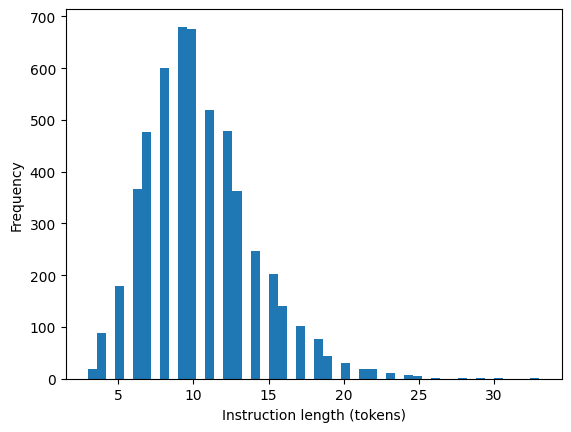

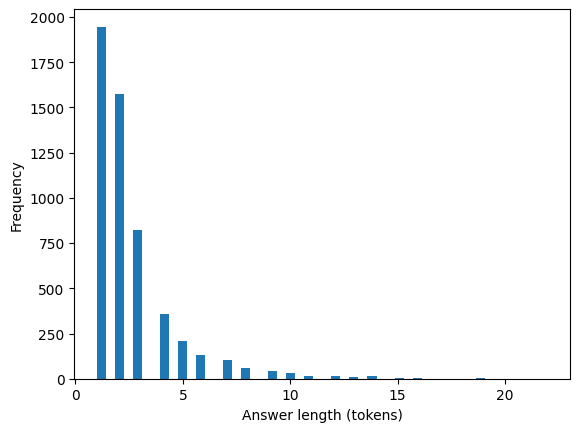

In [ ]:
# Identify token length distribution for questions and answers
plot_histogram(tokens_instructions, "Instruction length (tokens)")
print()
plot_histogram(tokens_answers, "Answer length (tokens)")

In [ ]:
# Most questions are of range 10-12 tokens
# Smallest question is 3 tokens
# Largest question is 33 tokens
pd.Series(tokens_instructions).describe()

,0
count,5351.000000
mean,10.364605
std,3.581564
min,3.000000
25%,8.000000
50%,10.000000
75%,12.000000
max,33.000000


In [ ]:
# Most answers are of range 2-3 tokens
# Smallest answer is 1 token (yes/no/digit)
# Largest answer is 22 tokens
pd.Series(tokens_answers).describe()

,0
count,5351.000000
mean,2.554663
std,2.138030
min,1.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,22.000000


In [ ]:
# Outliers calculated Q3 (75%) - Q1 (25%)
# Question outliers = 141/5351 = ~3%
# Answer outliers = 312/5351 = ~6%
outliers_instructions = find_outliers(tokens_instructions)
outliers_answers = find_outliers(tokens_answers)

len(outliers_instructions), len(outliers_answers)

(141, 312)

In [ ]:
# Presence of duplicates can be seen
instructions = [x["instruction"] for x in test_ds]
Counter(instructions).most_common(20)

[('How often do Parliament elections take place?', 2),
 ('What is needed to pack electrons densely together?', 2),
 ('What are the three sources of European Union law?', 2),
 ('What does the immune system protect against?', 2),
 ('What are two of its subsystems?', 2),
 ('Who won Super Bowl XLIX?', 2),
 ('Where did Maududi exert the most impact?', 2),
 ('Under what treaty can the European Commission take action against member states?',
  2),
 ('What did the non-Afghan veterans returning home have in addition to their prestige?',
  2),
 ('What is one problem with internet pharmacies?', 2),
 ('What was the theme of Super Bowl 50?', 2),
 ('Who won Super Bowl 50?', 2),
 ('What city did Super Bowl 50 take place in?', 2),
 ('Where did the Broncos practice for the Super Bowl?', 2),
 ('What did Luther think was required to stop the violence?', 1),
 ('What did Luther do during Lent at this time?', 1),
 ('How did Luther want people to bring about change?', 1),
 ('What troops attacked Fort William

In [ ]:
unique_instructions_ratio = unique_ratio(instructions)
unique_instructions_ratio

0.997383666604373

In [ ]:
# To check whether these are actual duplicates or not, we need to consider question-answer pairs
answers = [x["answer"] for x in test_ds]
Counter(answers).most_common(100)

[('three', 44),
 ('two', 31),
 ('four', 28),
 ('seven', 18),
 ('five', 17),
 ('six', 17),
 ('ten', 15),
 ('eight', 13),
 ('one', 12),
 ('nine', 12),
 ('miller', 12),
 ('new england patriots', 10),
 ('british', 9),
 ('oxygen', 9),
 ('peyton manning', 9),
 ('germany', 8),
 ('water', 8),
 ('third', 8),
 ('newton', 8),
 ('arizona cardinals', 8),
 ('linebacker', 7),
 ('second', 7),
 ('gold', 7),
 ('levis stadium', 7),
 ('denver broncos', 7),
 ('not', 6),
 ('broncos', 6),
 ('carolina panthers', 6),
 ('photosynthesis', 6),
 ('luther', 6),
 ('japan', 6),
 ('anderson', 6),
 ('german', 6),
 ('france', 6),
 ('san diego', 6),
 ('george westinghouse', 6),
 ('education', 6),
 ('united states', 6),
 ('economist', 5),
 ('catholic', 5),
 ('civil disobedience', 5),
 ('violence', 5),
 ('god', 5),
 ('warsaw', 5),
 ('lower', 5),
 ('half', 5),
 ('thomas edison', 5),
 ('los angeles', 5),
 ('the european court of justice', 5),
 ('inequality', 4),
 ('singing', 4),
 ('tesla coil', 4),
 ('jews', 4),
 ('general r

In [ ]:
unique_answers_ratio = unique_ratio(answers)
unique_answers_ratio

0.7863950663427397

In [ ]:
# Majority of dataset is made of 1-3 token answers
# It is good in a sense, will help us analyze accuracy of memory retention very objectively
short_answers = sum(l <= 3 for l in tokens_answers)
long_answers  = sum(l >= 10 for l in tokens_answers)
print("short answers:", short_answers)
print("long answers:", long_answers)

short answers: 4341
long answers: 101


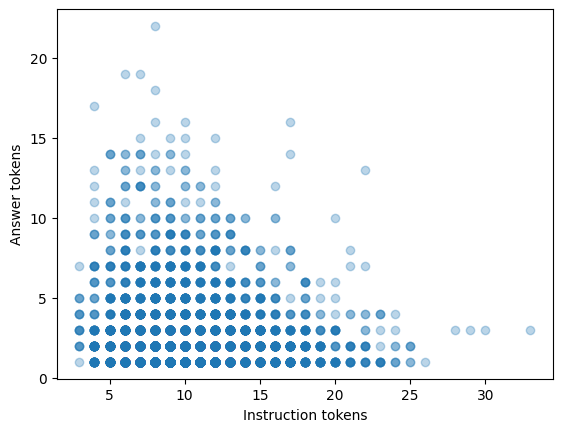

In [ ]:
scatter_plot(tokens_instructions, tokens_answers)

In [15]:
# 13 question-answer pairs are duplicate
pairs = [(x["instruction"], x["answer"]) for x in test_ds]
duplicate_count = len(pairs) - len(set(pairs))
duplicate_count

13

In [16]:
# remove duplicate question-answer pairs (13)
seen = set()
indices_to_keep = []

for i, example in enumerate(test_ds):
    key = (example["instruction"], example["answer"])
    if key not in seen:
        seen.add(key)
        indices_to_keep.append(i)

test_ds_unique = test_ds.select(indices_to_keep)

print(f"Original size: {len(test_ds)}")
print(f"After deduplication: {len(test_ds_unique)}")

Original size: 5351
After deduplication: 5338


In [17]:
pairs = [(x["instruction"], x["answer"]) for x in test_ds_unique]
duplicate_count = len(pairs) - len(set(pairs))
duplicate_count

0

### Analysis of uniqueness in answers
Since the answers are short and seem repetitive, we will analyze them in more depth to see if they hold a good uniqueness value

In [ ]:
df = pd.DataFrame(test_ds_unique)
df["answer_tokens"] = df["answer"].apply(lambda x: x.strip().split())
df["answer_len"] = df["answer_tokens"].apply(len)

In [ ]:
# Answers > 1 token have a high uniqueness ratio
uniqueness_stats = (
    df.groupby("answer_len")["answer"]
      .agg(
          total_count="count",
          unique_count=pd.Series.nunique
      )
      .reset_index()
)

uniqueness_stats["uniqueness_ratio"] = (
    uniqueness_stats["unique_count"] / uniqueness_stats["total_count"]
)

uniqueness_stats

,answer_len,total_count,unique_count,uniqueness_ratio
0,1,1943,1226,0.630983
1,2,1569,1285,0.818993
2,3,819,749,0.914530
3,4,359,341,0.949861
4,5,209,193,0.923445
5,6,130,129,0.992308
6,7,105,99,0.942857
7,8,60,55,0.916667
8,9,44,39,0.886364
9,10,34,30,0.882353


In [ ]:
short_df = df[df["answer_len"].isin([1, 2])]

In [ ]:
one_token_answers = df[df["answer_len"] == 1]["answer"]
Counter(one_token_answers).most_common(10)

[('three', 44),
 ('two', 31),
 ('four', 28),
 ('seven', 18),
 ('five', 17),
 ('six', 17),
 ('ten', 15),
 ('eight', 13),
 ('one', 12),
 ('nine', 12)]

In [ ]:
two_token_answers = df[df["answer_len"] == 2]["answer"]
Counter(two_token_answers).most_common(10)

[('peyton manning', 9),
 ('arizona cardinals', 8),
 ('levis stadium', 7),
 ('carolina panthers', 6),
 ('san diego', 6),
 ('george westinghouse', 6),
 ('united states', 6),
 ('denver broncos', 6),
 ('civil disobedience', 5),
 ('thomas edison', 5)]

In [ ]:
# Dominance ratio < 5% signifies high diversity
dominance_1 = dominance_ratio(one_token_answers)
dominance_2 = dominance_ratio(two_token_answers)

dominance_1, dominance_2

(0.022645393721049924, 0.0057361376673040155)

In [ ]:
# Higher entropy = higher lexical diversity
entropy_1 = entropy(one_token_answers)
entropy_2 = entropy(two_token_answers)

entropy_1, entropy_2

(9.75993646788866, 10.174634723990348)

In [ ]:
freqs_1 = sorted(Counter(one_token_answers).values(), reverse=True)
freqs_2 = sorted(Counter(two_token_answers).values(), reverse=True)

freqs_1[:10], freqs_1[-10:]

([44, 31, 28, 18, 17, 17, 15, 13, 12, 12], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
summary = pd.DataFrame({
    "Answer Length": [1, 2],
    "Total Samples": [len(one_token_answers), len(two_token_answers)],
    "Unique Answers": [
        one_token_answers.nunique(),
        two_token_answers.nunique()
    ],
    "Uniqueness Ratio": [
        one_token_answers.nunique() / len(one_token_answers),
        two_token_answers.nunique() / len(two_token_answers)
    ],
    "Dominance Ratio": [dominance_1, dominance_2],
    "Entropy": [entropy_1, entropy_2]
})

summary

,Answer Length,Total Samples,Unique Answers,Uniqueness Ratio,Dominance Ratio,Entropy
0,1,1943,1226,0.630983,0.022645,9.759936
1,2,1569,1285,0.818993,0.005736,10.174635


### Analysis of audio field

In [18]:
# decode audio field now as we will analyze it
test_ds_unique = test_ds_unique.cast_column("context", Audio(decode=True))

In [ ]:
test_ds_unique[0]

{'context': <datasets.features._torchcodec.AudioDecoder at 0x7bda37a453a0>,
 'instruction': 'What did Luther think was required to stop the violence?',
 'answer': 'personal presence',
 'duration_sec': 48.84}

In [19]:
test_ds_unique = test_ds_unique.map(
    lambda x: {"duration_sec": duration(x["context"])}
)

Map:   0%|          | 0/5338 [00:00<?, ? examples/s]

In [ ]:
df_audio = test_ds_unique.to_pandas()

In [ ]:
# Length of audio segments lies between 12 sec to 5 min
# Majority of the audio segments lie around the 60 sec mark
df_audio["duration_sec"].describe()

,duration_sec
count,5338.000000
mean,61.028763
std,28.219552
min,11.568000
25%,44.328000
50%,55.392000
75%,71.784000
max,305.304000


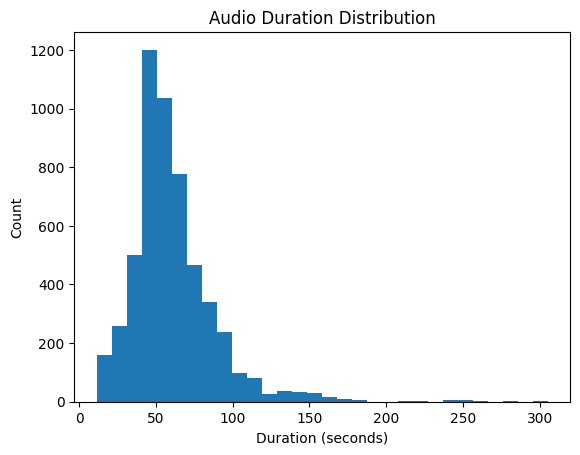

In [ ]:
plt.figure()
plt.hist(df_audio["duration_sec"], bins=30)
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.title("Audio Duration Distribution")
plt.show()

In [ ]:
df_audio["duration_bin"] = pd.cut(
    df_audio["duration_sec"],
    bins=[0,5,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,300]
)

df_audio["duration_bin"].value_counts().sort_index()

,count
duration_bin,
"(0, 5]",0
"(5, 10]",0
"(10, 20]",133
"(20, 30]",247
"(30, 40]",422
"(40, 50]",1226
"(50, 60]",1086
"(60, 70]",789
"(70, 80]",498


In [ ]:
test_ds_unique = test_ds_unique.map(
    lambda x: {"sampling_rate": x["context"]["sampling_rate"]}
)

Map:   0%|          | 0/5338 [00:00<?, ? examples/s]

In [ ]:
test_ds_unique = test_ds_unique.map(
    lambda x: {"snr": estimate_snr(x["context"])}
)

Map:   0%|          | 0/5338 [00:00<?, ? examples/s]

In [ ]:
test_ds_unique = test_ds_unique.map(
    lambda x: {"snrv2": estimate_snr_v2(x["context"])}
)

Map:   0%|          | 0/5338 [00:00<?, ? examples/s]

In [ ]:
df_audio = test_ds_unique.to_pandas()

In [ ]:
df_audio["duration_sec"].describe()

In [ ]:
df_audio["sampling_rate"].describe()

,sampling_rate
count,5338.0
mean,16000.0
std,0.0
min,16000.0
25%,16000.0
50%,16000.0
75%,16000.0
max,16000.0


In [ ]:
# Sampling rate is same and consistent, no need for normalization
df_audio["sampling_rate"].value_counts()

,count
sampling_rate,
16000,5338


In [ ]:
pd.set_option("display.float_format", "{:.20f}".format)

In [ ]:
# SNR values clustered around zero suggest that the chosen estimation method does not offer very good insights
# audio is very clear when studied manually - limited interpretability - need to find a different method to measure SNR if possible
df_audio["snr"].describe()

,snr
count,5338.00000000000000000000
mean,-0.00000014446300156123
std,0.00000083974970266354
min,-0.00000258859745372320
25%,-0.00000077657915653617
50%,-0.00000025885969989758
75%,0.00000051771934295175
max,0.00000776578326622257


In [ ]:
df_audio["snrv2"].describe()

,snrv2
count,5338.00000000000000000000
mean,12.43238353729248046875
std,1.04177331924438476562
min,9.21965503692626953125
25%,11.70386505126953125000
50%,12.35213661193847656250
75%,13.02470207214355468750
max,19.25238037109375000000


###Removal of outliers

In [20]:
durations = test_ds_unique["duration_sec"]

In [21]:
import numpy as np

Q1 = np.percentile(durations, 25)
Q3 = np.percentile(durations, 75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [22]:
# as seen in distribution above, there are no entries lesser than or equal to the lower bound
# so we are essentially only trimming upper bound
print(lower_bound)
print(upper_bound)

3.1439999999999984
112.96800000000002


In [23]:
test_ds_unique = test_ds_unique.filter(
    lambda x: lower_bound <= x["duration_sec"] <= upper_bound
)

Filter:   0%|          | 0/5338 [00:00<?, ? examples/s]

In [24]:
print("Original size:", len(durations))
print("Filtered size:", len(test_ds_unique))

Original size: 5338
Filtered size: 5119


In [25]:
test_ds_unique = test_ds_unique.map(
    lambda x: {
        "instruction_len": len(x["instruction"].split()),
        "answer_len": len(x["answer"].split())
    }
)

Map:   0%|          | 0/5119 [00:00<?, ? examples/s]

In [26]:
instruction_lengths = test_ds_unique["instruction_len"]
answer_lengths = test_ds_unique["answer_len"]

In [27]:
# Questions
Q1_q = np.percentile(instruction_lengths, 25)
Q3_q = np.percentile(instruction_lengths, 75)
IQR_q = Q3_q - Q1_q

lower_q = Q1_q - 1.5 * IQR_q
upper_q = Q3_q + 1.5 * IQR_q

# Answers
Q1_a = np.percentile(answer_lengths, 25)
Q3_a = np.percentile(answer_lengths, 75)
IQR_a = Q3_a - Q1_a

lower_a = Q1_a - 1.5 * IQR_a
upper_a = Q3_a + 1.5 * IQR_a

In [28]:
# since the lower bounds for both do not contain even a single entry (refer to distribution above)
# we will filter only upper bound
print(lower_q)
print(upper_q)
print(lower_a)
print(upper_a)

2.0
18.0
-2.0
6.0


In [29]:
test_ds_unique = test_ds_unique.filter(
    lambda x: x["instruction_len"] <= upper_q
)

Filter:   0%|          | 0/5119 [00:00<?, ? examples/s]

In [30]:
test_ds_unique = test_ds_unique.filter(
    lambda x: x["answer_len"] <= upper_a
)

Filter:   0%|          | 0/4986 [00:00<?, ? examples/s]

In [31]:
print(len(test_ds_unique))

4704


### Save final dataset

In [ ]:
!rm -rf ~/.cache/huggingface
!rm -rf ~/.huggingface

In [ ]:
login()

In [ ]:
# https://huggingface.co/datasets/byteCode18/spoken-squad-memory-eval

repo_name = "spoken-squad-memory-eval"

test_ds_unique.push_to_hub(
    repo_name,
    private=True
)

Uploading the dataset shards:   0%|          | 0/18 [00:00<?, ? shards/s]

Map:   0%|          | 0/262 [00:00<?, ? examples/s]

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Creating parquet from Arrow format:   0%|          | 0/3 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              :   0%|          |  492kB /  163MB            

CommitInfo(commit_url='https://huggingface.co/datasets/byteCode18/spoken-squad-memory-eval/commit/14fab10885ac60c3bbae1d26a4108224a972d030', commit_message='Upload dataset', commit_description='', oid='14fab10885ac60c3bbae1d26a4108224a972d030', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/byteCode18/spoken-squad-memory-eval', endpoint='https://huggingface.co', repo_type='dataset', repo_id='byteCode18/spoken-squad-memory-eval'), pr_revision=None, pr_num=None)

In [ ]:

#test load dataset: byteCode18/spoken-squad-1k-memory-eval
sub_ds = load_dataset("byteCode18/spoken-squad-memory-eval")

README.md:   0%|          | 0.00/494 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

data/test-00000-of-00018.parquet:   0%|          | 0.00/143M [00:00<?, ?B/s]

data/test-00001-of-00018.parquet:   0%|          | 0.00/191M [00:00<?, ?B/s]

...

data/test-00014-of-00018.parquet:   0%|          | 0.00/132M [00:00<?, ?B/s]

data/test-00015-of-00018.parquet:   0%|          | 0.00/173M [00:00<?, ?B/s]

data/test-00016-of-00018.parquet:   0%|          | 0.00/155M [00:00<?, ?B/s]

data/test-00017-of-00018.parquet:   0%|          | 0.00/163M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4704 [00:00<?, ? examples/s]

In [ ]:
len(sub_ds['test'])

4704

In [ ]:
sub_ds['test'].features

{'context': Audio(sampling_rate=None, decode=True, stream_index=None),
 'instruction': Value('string'),
 'answer': Value('string'),
 'duration_sec': Value('float64'),
 'instruction_len': Value('int64'),
 'answer_len': Value('int64')}